# Hochschule Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Hochschule Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/059vymd37' -- 'Hochschule Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Osnabrück,From the University of Applied Sciences Osnabr...,https://openalex.org/W4391558381
1,not assigned,Hochschule Osnabrück,"University of Applied Sciences Osnabrück, Facu...",https://openalex.org/W4391558381
2,not assigned,Hochschule Osnabrück,Faculty of Business and Social Sciences Univer...,https://openalex.org/W4399096004
3,not assigned,Hochschule Osnabrück,Faculty of Business Management and Social Scie...,https://openalex.org/W4405207994
4,not assigned,Hochschule Osnabrück,"Faculty of Business and Social Sciences, Hochs...",https://openalex.org/W4398251068


In [2]:
MAPPING_DICT = {
    #'Department für Duale Studiengänge (DDS)': [],
    'Fakultät Management, Kultur und Technik': ['faculty of management', '(management|kultur) (und|and) (techn(ik|ology)|kultur)'],
    #'Institut für Kommunikationsmanagement': [],
    #'Institut für Theaterpädagogik': [],
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': ['agrarwissenschaften', 'agricultur(e|al)', 'horticultural', 'poultry', 'pflanzenschutz', 'ecology',
                                                                'nutrition', 'plant breeding', 'pflanzenernährung', 'landwirtschaftlich', 'tierhaltung'
                                                               ],
    'Fakultät Ingenieurwissenschaften und Informatik': ['computer (science|engineering)', 'material(s)? design', 'ingenieurwissenschaften', 'chemistry',
                                                        'verfahrenstechnik', 'thermodynamik', 'plastics'
                                                       ],
    'Fakultät Wirtschafts- und Sozialwissenschaften': ['social (science|studies)', 'sozialwissenschaft(t)?en', 'economic sciences'],
    #'Forschungszentrum Energiewirtschaft Energierecht (FEE)': [],
    'Forschungszentrum für Gesundheits- und Sozialinformatik': ['health informatics', 'social informatics'], # selbst ergänzt
    #'Institut für Musik': [],
    #'Kompetenzzentrum Globale Kompetenz': []
}

In [3]:
with open('./mapping_tables_fak/hsosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [230]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [231]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [232]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,From the University of Applied Sciences Osnabr...,https://openalex.org/W4391558381
1,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,"University of Applied Sciences Osnabrück, Facu...",https://openalex.org/W4391558381
2,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,Faculty of Business and Social Sciences Univer...,https://openalex.org/W4399096004
3,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,Faculty of Business Management and Social Scie...,https://openalex.org/W4405207994
4,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,"Faculty of Business and Social Sciences, Hochs...",https://openalex.org/W4398251068
...,...,...,...,...
1022,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,"Department of Economic and Social Sciences, Un...",https://openalex.org/W4292623458
1023,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,School of Business Management and Social Scien...,https://openalex.org/W4283158923
1024,None,Hochschule Osnabrück,Division of Vegetable Production and Processin...,https://openalex.org/W3171156305
1025,"Fakultät Management, Kultur und Technik",Hochschule Osnabrück,"Faculty of Management, Culture, and Technology...",https://openalex.org/W4406850287


In [233]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[20:]

array(['Hochschule Osnabrück - University of Applied Sciences',
       'Hochschule Osnabrück - University of Applied Sciences/University of Alberta',
       'Osnabrück University of Applied Sciences  Osnabrück Germany',
       'OS UAS - Osnabrück University of Applied Sciences (Germany)',
       'Osnabrück University of Applied Sciences, Lingen (Ems), Germany',
       'Osnabrück University of Applied Sciences, Osnabrück, Germany',
       'Department of Physical Therapy and Rehabilitation Science, Osnabrück University of Applied Sciences, Albrechtstr. 30, 49076 Osnabrück, Germany',
       'Hochschule Osnabrück, Campus Lingen (Ems)',
       'Federal University of São Carlos/Hochschule Osnabrück - University of Applied Sciences',
       'GesundheitsCampus Osnabrück, Osnabrück University of AS, Germany',
       'University of Applied Science, Osnabrück, Germany',
       'Hochschule Osnabruck, Osnabruck, Germany',
       'University of Applied Sciences Osnabrueck, Osnabruck, Germany',
     

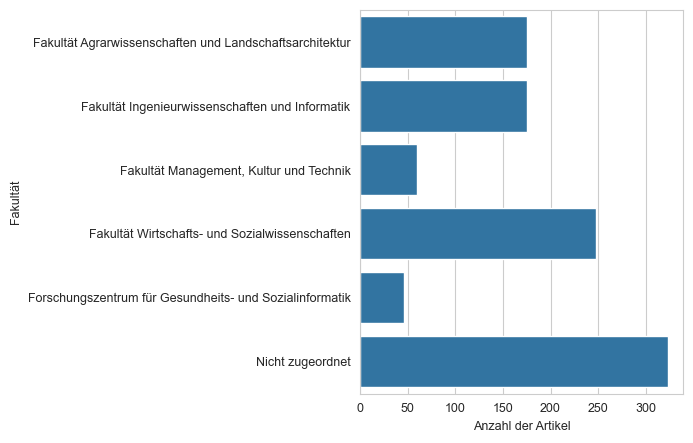

In [234]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [235]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.685491723466407